LINEAR REGRESSION


In [ ]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn Utilities
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics


In [ ]:
# Load the dataset
df = pd.read_csv('/content/diabetes.csv')

# Display first few rows
print(df.head())

# Dataset shape
print("\nDataset Shape:", df.shape)


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape: (768, 9)


In [ ]:
# Columns where zero is not biologically valid
invalid_zero_cols = ['Glucose', 'BloodPressure', 'BMI']

# Replace 0 with NaN
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

# Fill NaN values with column mean
df[invalid_zero_cols] = df[invalid_zero_cols].fillna(df[invalid_zero_cols].mean())

# Verify missing values
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())



Missing Values After Cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


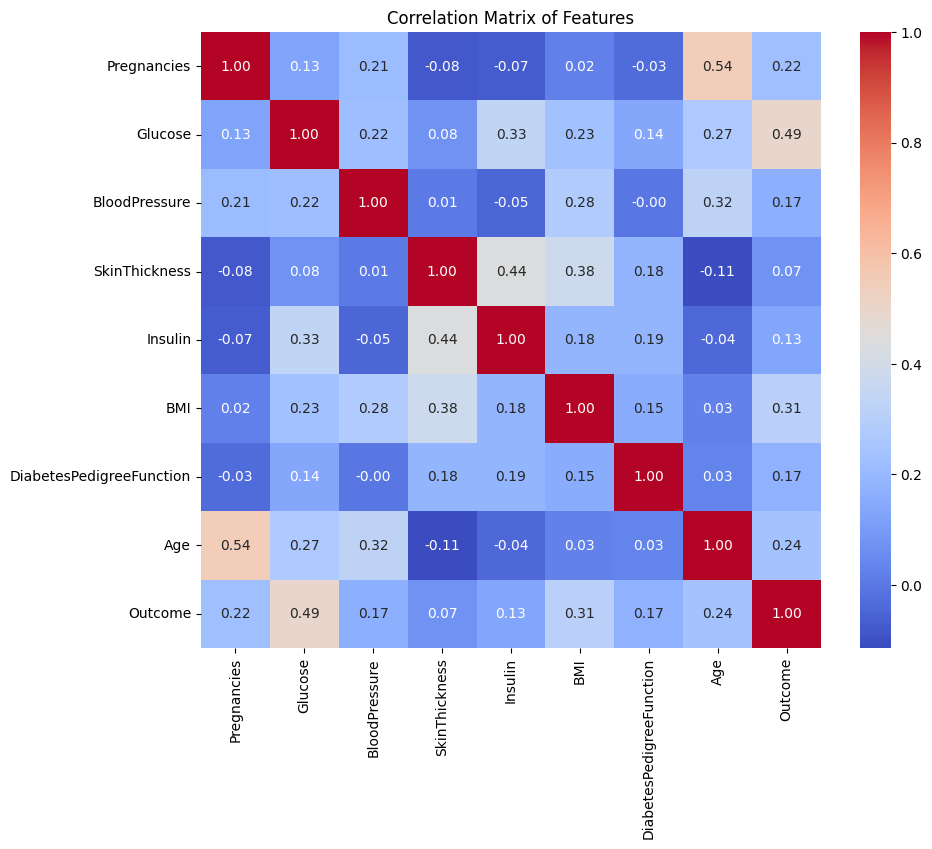

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.show()


In [ ]:
# Independent Variables
X = df[['BMI', 'Age', 'BloodPressure']]

# Dependent Variable
y = df['Glucose']


In [ ]:
# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (614, 3)
Testing set size: (154, 3)


In [ ]:
# Initialize model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
# Predict on test data
y_pred = model.predict(X_test)


In [ ]:
# Performance Metrics
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

# Mean Absolute Percentage Error
mape = np.mean(np.abs((y_test - y_pred) / y_test))

print("\n--- Model Performance Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (R²): {r2:.4f} ({r2*100:.2f}%)")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f} ({mape*100:.2f}%)")



--- Model Performance Metrics ---
Mean Absolute Error (MAE): 24.6911
Mean Squared Error (MSE): 894.2202
Root Mean Squared Error (RMSE): 29.9035
R-squared Score (R²): 0.1114 (11.14%)
Mean Absolute Percentage Error (MAPE): 0.2195 (21.95%)


In [ ]:
print("\n--- Regression Coefficients ---")
coeff_df = pd.DataFrame(
    model.coef_,
    X.columns,
    columns=['Coefficient']
)
print(coeff_df)

print(f"\nIntercept (β₀): {model.intercept_:.4f}")



--- Regression Coefficients ---
               Coefficient
BMI               0.895345
Age               0.658042
BloodPressure     0.174362

Intercept (β₀): 58.6273


In [ ]:
equation = (
    f"Glucose = {model.intercept_:.4f} "
    f"+ ({model.coef_[0]:.4f} × BMI) "
    f"+ ({model.coef_[1]:.4f} × Age) "
    f"+ ({model.coef_[2]:.4f} × BloodPressure)"
)

print("\n--- Final Regression Equation ---")
print(equation)



--- Final Regression Equation ---
Glucose = 58.6273 + (0.8953 × BMI) + (0.6580 × Age) + (0.1744 × BloodPressure)


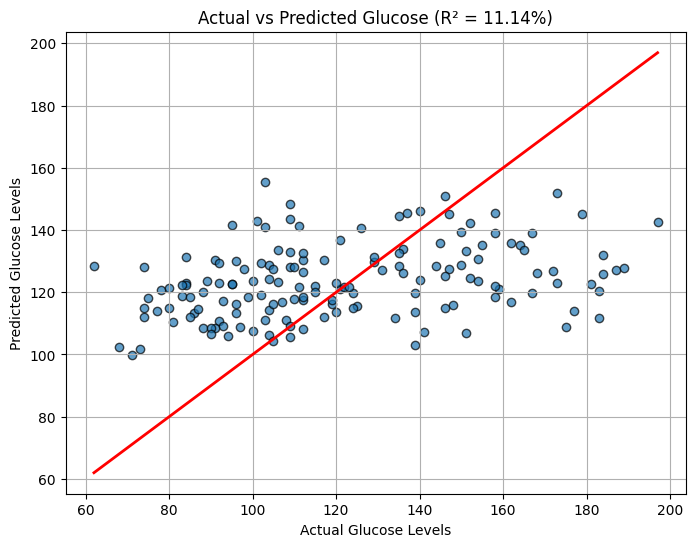

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7, edgecolor='k')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)
plt.xlabel("Actual Glucose Levels")
plt.ylabel("Predicted Glucose Levels")
plt.title(f"Actual vs Predicted Glucose (R² = {r2*100:.2f}%)")
plt.grid(True)
plt.show()


--- Model Metrics ---
Regression Equation: Glucose = -77.08 + (1.30 * BMI)
R-squared: 0.0871
Mean Absolute Error: 82.83


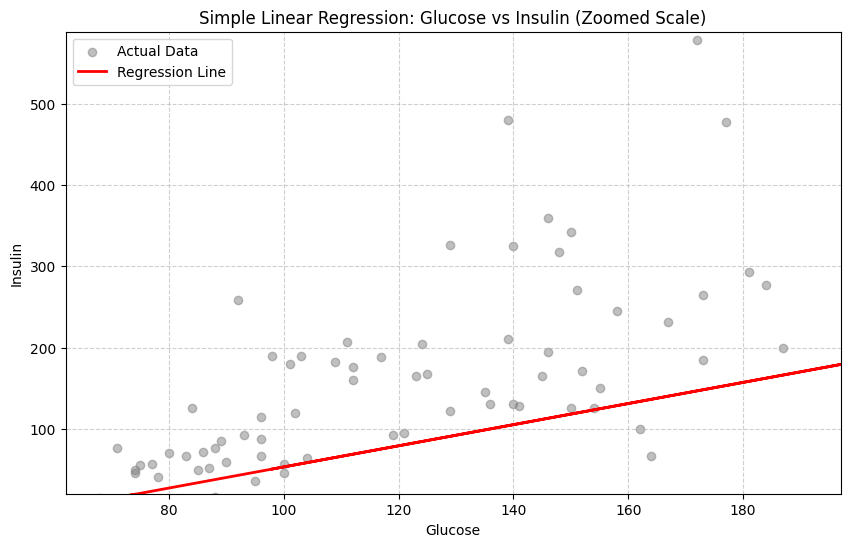

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# 1. Load Dataset
df = pd.read_csv("diabetes.csv")

# 2. Data Cleaning (Handling 0s)
# Replacing 0 with NaN for biologically impossible values, then imputing with mean
df[['Glucose', 'BMI']] = df[['Glucose', 'BMI']].replace(0, np.nan)
df['Glucose'] = df['Glucose'].fillna(df['Glucose'].mean())
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())

# 3. Feature Selection (Simple Linear Regression = One Feature)
X = df[['Glucose']]
y = df['Insulin']

# 4. Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Training the Model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Prediction & Evaluation
y_pred = model.predict(X_test)

print("--- Model Metrics ---")
print(f"Regression Equation: Glucose = {model.intercept_:.2f} + ({model.coef_[0]:.2f} * BMI)")
print(f"R-squared: {metrics.r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {metrics.mean_absolute_error(y_test, y_pred):.2f}")

# 7. Visualization
# 7. Visualization (Enlarged Scale)
plt.figure(figsize=(10, 6))

# Scatter plot of Actual Data
plt.scatter(X_test, y_test, color='gray', alpha=0.5, label="Actual Data")

# Regression Line
plt.plot(X_test, y_pred, color='red', linewidth=2, label="Regression Line")

# --- ADJUSTING THE SCALE ---
# Ignore the bottom cluster by setting a minimum Insulin (Y) value
# Example: Start Y-axis at 50 to see the spread of higher values
plt.ylim(20, y_test.max() + 10)
plt.xlim(X_test.min().values[0], X_test.max().values[0])
# ---------------------------

plt.xlabel("Glucose")
plt.ylabel("Insulin")
plt.title("Simple Linear Regression: Glucose vs Insulin (Zoomed Scale)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


**LOGISTIC REGRESSION**

In [ ]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn Utilities
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


In [ ]:
df = pd.read_csv("diabetes.csv")

print(df.head())
print("\nDataset Shape:", df.shape)


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape: (768, 9)


In [ ]:
# Columns where 0 is invalid
invalid_zero_cols = ['Glucose', 'BloodPressure', 'BMI', 'SkinThickness', 'Insulin']

# Replace 0 with NaN
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

# Fill NaN with column mean
df[invalid_zero_cols] = df[invalid_zero_cols].fillna(df[invalid_zero_cols].mean())

# Verify
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())



Missing Values After Cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# Independent variables
X = df.drop('Outcome', axis=1)

# Target variable
y = df['Outcome']


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 614
Testing samples: 154


In [ ]:
# Parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}

# Grid Search
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

# Train model
grid.fit(X_train, y_train)

print("\nBest Parameters Found:")
print(grid.best_params_)



Best Parameters Found:
{'C': 0.1, 'solver': 'liblinear'}


In [ ]:
# Best model
best_model = grid.best_estimator_

# Predictions
y_pred = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)[:, 1]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("\n--- Model Performance Metrics ---")
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"ROC-AUC Score: {roc_auc:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))



--- Model Performance Metrics ---
Accuracy: 0.7013 (70.13%)
ROC-AUC Score: 0.8093

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.75      0.80      0.78       100
           1       0.58      0.52      0.55        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154



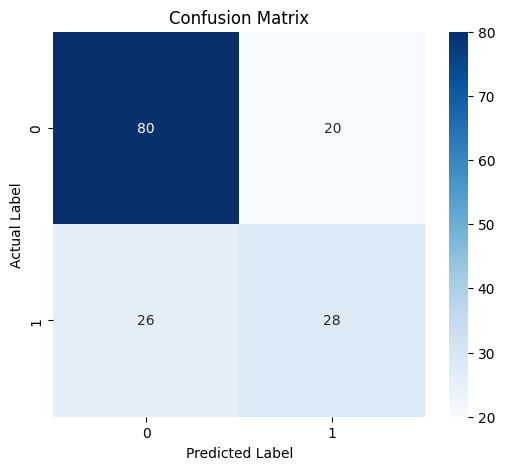

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()


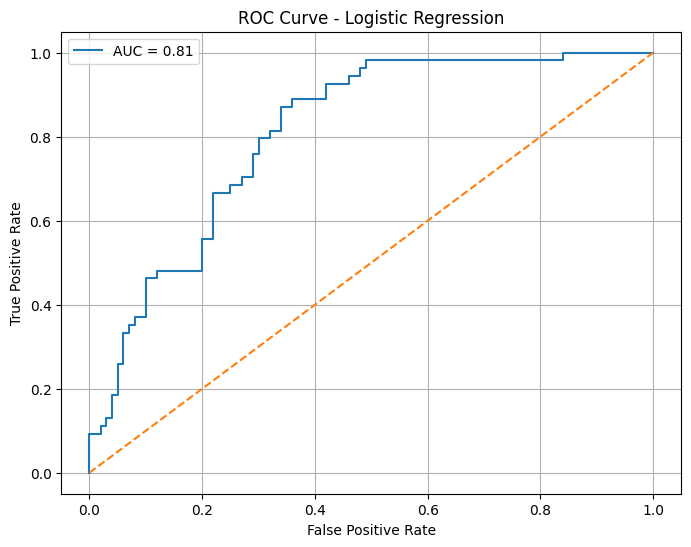

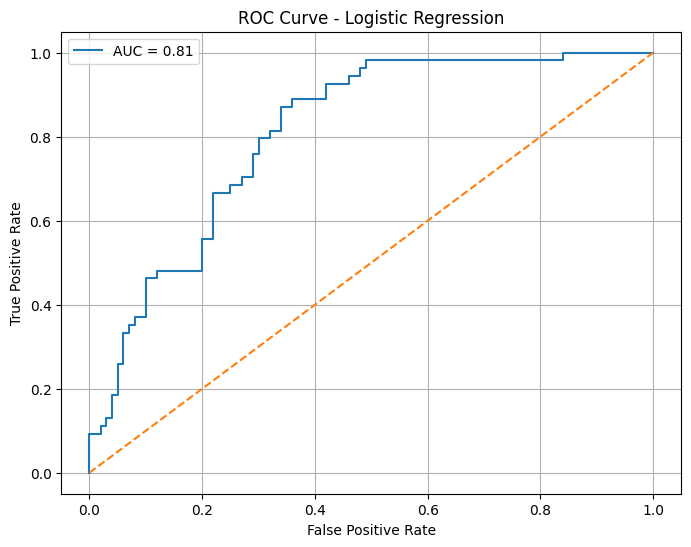

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)



In [ ]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("\n--- Feature Coefficients ---")
print(coeff_df)



--- Feature Coefficients ---
                    Feature  Coefficient
1                   Glucose     1.008424
5                       BMI     0.568149
0               Pregnancies     0.321082
6  DiabetesPedigreeFunction     0.207980
7                       Age     0.148733
3             SkinThickness     0.061360
4                   Insulin     0.031398
2             BloodPressure     0.000327


In [ ]:
intercept = best_model.intercept_[0]

print("\n--- Logistic Regression Equation ---")
print(f"z = {intercept:.4f} ", end="")
for coef, feature in zip(best_model.coef_[0], X.columns):
    print(f"+ ({coef:.4f} × {feature}) ", end="")

print("\n\nP(Diabetes) = 1 / (1 + e^-z)")



--- Logistic Regression Equation ---
z = -0.7566 + (0.3211 × Pregnancies) + (1.0084 × Glucose) + (0.0003 × BloodPressure) + (0.0614 × SkinThickness) + (0.0314 × Insulin) + (0.5681 × BMI) + (0.2080 × DiabetesPedigreeFunction) + (0.1487 × Age) 

P(Diabetes) = 1 / (1 + e^-z)
